# This notebook is a demonstration of running the combined peak ranging and peak ion identification ML models

Ryan Jacobs, based on original code from Jingrui Wei

Last updated: 12/8/25 by Ryan Jacobs


# Install and setup for Google Colab

In [1]:
# Link Google drive

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# Clone repo

!git clone https://github.com/uw-cmg/peak_detection

Cloning into 'peak_detection'...
remote: Enumerating objects: 20745, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 20745 (delta 30), reused 15 (delta 6), pack-reused 20675 (from 4)
Receiving objects: 100% (20745/20745), 120.17 MiB | 21.66 MiB/s, done.
Resolving deltas: 100% (382/382), done.
Updating files: 100% (20083/20083), done.


In [3]:
# Install dependencies. Now only takes < 1 min

!uv pip install -r "peak_detection/requirements.txt"

Using Python 3.12.12 environment at: /usr
Resolved 80 packages in 1.98s
Prepared 18 packages in 48.48s
Installed 18 packages in 72ms
 + apav==1.4.0
 + asteval==1.0.7
 + bibtexparser==1.4.3
 + colorama==0.4.6
 + fast-histogram==0.14
 + lmfit==1.3.4
 + monty==2025.3.3
 + palettable==3.3.3
 + periodictable==2.0.2
 + pymatgen==2025.10.7
 + pyqt5==5.15.11
 + pyqt5-qt5==5.15.18
 + pyqt5-sip==12.17.2
 + pyqtgraph==0.14.0
 + ruamel-yaml==0.18.16
 + ruamel-yaml-clib==0.2.15
 + spglib==2.6.0
 + uncertainties==3.2.3


In [4]:
# For Colab, move repo directories so imports work

import shutil
shutil.move('peak_detection', 'peak_detection_repo')
shutil.move('peak_detection_repo/peak_detection', '.')

'./peak_detection'

# Import needed packages

In [5]:
import apav
import os
import re
import pandas as pd
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import torch.nn.functional as F
from scipy.signal import find_peaks
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import yaml
from pathlib import Path
import joblib
from pymatgen.core import Composition
import pandas as pd
import glob
import subprocess
import itertools

import peak_detection
from peak_detection.RangingNN.predictor import DetectionPredictor
from peak_detection.RangingNN.metrics import box_iou
from peak_detection.RangingNN.model_utils import cw2lh




/usr/local/lib/python3.12/dist-packages/apav/core/range.py:332: SyntaxWarning: invalid escape sequence '\*'
  Build RangeCollection from \*.rrng files
/content/peak_detection/RangingNN/predictor.py:205: SyntaxWarning: invalid escape sequence '\ '
  LOGGER.info(f"Results saved to {self.save_dir} \ results_range_indexes.pt ")


# Function definitions to do model predictions and visualization

In [6]:
def map01(ar):
    return (ar-ar.min()) / (ar.max()-ar.min())

def load_apt(apt_file):
    '''

    '''
    # Load the .apt file and get histogram
    d = apav.load_apt(apt_file)
    x, spectrum = d.mass_histogram(bin_width=0.01, lower=0, upper=307.2, multiplicity='all', norm=False,)
    spectrum_log = torch.tensor(map01(np.log(spectrum+1)), dtype=torch.float32)
    return spectrum, spectrum_log

def sort_predictions(peak_range_pred, elements):
    peak_range_pred_sort = peak_range_pred[peak_range_pred[:, 0].argsort()]
    inds = list(peak_range_pred[:, 0].argsort())
    inds = [int(i) for i in inds]
    elements_sort = [elements[i] for i in inds]
    return peak_range_pred_sort, elements_sort

def predict_peak_ranges(apt_file,
                        conf=0.05,
                        iou=0.01,
                        max_det=2000,
                        modelpath='/content/peak_detection/RangingNN/modelweights/best.pt',
                        from_custom_spectrum=False,
                        spectrum_log=None,
                        n_iter=0,
                        mc_min=None,
                        mc_max=None):
    '''
    HERE peak ranges
    '''

    if from_custom_spectrum == False:
        spectrum, spectrum_log = load_apt(apt_file=apt_file)

    # Load in the RangingNN model and do the peak detection
    #cfg = os.path.dirname(peak_detection.__file__) + '/RangingNN/cfg/prediction_args.yaml' # loading the default parameter file in the package
    cfg = 'peak_detection/RangingNN/cfg/prediction_args.yaml' # loading the default parameter file in the package
    cfg = yaml.safe_load(Path(cfg).read_text())

    cfg['iou'] = iou
    cfg['conf'] = conf
    cfg['max_det'] = max_det

    #modelpath = os.path.join(os.path.dirname(peak_detection.__file__), 'RangingNN/modelweights/best.pt') # loading the default trained-model in the package
    #print('spectrum log')
    #print(spectrum_log.shape)
    #print(spectrum_log)

    predictor = DetectionPredictor(modelpath, spectrum_log[None, None, ...], save_dir = 'test_results', cfg = cfg)
    result = predictor()[0]
    peak_range_pred = result[:,:2].cpu()
    counts = result[:,2].cpu()

    print('model predicted peaks:',peak_range_pred.shape[0])
    peak_range_toadd = list()
    counts_toadd = list()
    if n_iter > 0:
        for i in range(n_iter):
            print('On ranging model iteration', i)
            # Remove the old predicted peaks, run the model again, and keep any new found peaks
            idx_delete = list()
            multiplier = 0.01
            x1 = np.linspace(0.0, spectrum_log.shape[0]*0.01, spectrum_log.shape[0])

            print('Processing spectrum part 1')
            n = spectrum_log.shape[0]
            x1 = np.arange(n) * multiplier   # equivalent to your linspace
            # peak_range_pred: list of (start, end)
            ranges = np.asarray(peak_range_pred, dtype=float)   # shape (R, 2)
            starts = ranges[:, 0] * multiplier                  # shape (R,)
            ends   = ranges[:, 1] * multiplier                  # shape (R,)

            # Broadcasting: shape (n, R), then reduce along R
            in_any_range = np.logical_or.reduce(
                (x1[:, None] > starts[None, :]) &
                (x1[:, None] < ends[None, :]),
                axis=1
            )

            idx_delete = x1[in_any_range]
            #for i, j in zip(x1, spectrum_log):
            #    for start, end in peak_range_pred:
            #        if start*multiplier < i < end*multiplier:
            #            idx_delete.append(i)


            #print('idx delete shape', len(idx_delete))
            # Sub a constant 0.2 in for now
            #spectrum_log_mod = list()
            #for i, j in zip(x1, spectrum_log):
            #    if i in idx_delete:
            #        spectrum_log_mod.append(0.2)
            #    else:
            #        spectrum_log_mod.append(j)

            print('Processing spectrum part 2')
            x1 = np.asarray(x1)
            spectrum_log = np.asarray(spectrum_log)
            mask = np.isin(x1, idx_delete)

            spectrum_log_mod = spectrum_log.copy()
            spectrum_log_mod[mask] = 0.2

            spectrum_log_mod = torch.Tensor(spectrum_log_mod)

            print('Running predictions')
            predictor_mod = DetectionPredictor(modelpath, spectrum_log_mod[None, None, ...], save_dir = 'test_results', cfg = cfg)
            result_mod = predictor_mod()[0]
            peak_range_pred_mod = result_mod[:,:2].cpu()
            counts_mod = result_mod[:,2].cpu()

            print('peak range mod shape', peak_range_pred_mod.shape)
            #peak_range_pred_mod, counts_mod, result_mod = predict_peak_ranges(apt_file,
            #                                                                  conf=conf,
            #                                                                  iou=iou,
            #                                                                  max_det=max_det,
            #                                                                  modelpath=modelpath,
            #                                                                  from_custom_spectrum=True,
            #                                                                  spectrum_log=spectrum_log_mod,
            #                                                                  n_iter=1)

            # Collect any new peaks and append to the original list
            print('Processing newly detected peaks')
            tol = 0.5
            for i, count in zip(peak_range_pred_mod, counts_mod):
                start = float(i[0])
                end = float(i[1])
                max_iou = 1.0
                min_dist = 1000
                for j in peak_range_pred.tolist():

                    start2 = float(j[0])
                    end2 = float(j[1])
                    #print(abs(start-start2))
                    iou = calculate_iou_1d(interval1=[start, end], interval2=[start2, end2])
                    #ious.append(iou)
                    if iou < max_iou:
                        max_iou = iou

                        #start_found = start
                    if multiplier*abs(float(start)-float(start2)) < min_dist:
                        min_dist = multiplier*abs(float(start)-float(start2))
                    #print(start, start2, max_iou, min_dist)
                    #    # New peak found
                    #    print('HERE found new')
                    #    peak_range_toadd.append([start, end])
                    #    counts_toadd.append(count)
                # Want max iou to be 0 -> totally new peak
                #print('Max iou is', max_iou)
                if max_iou == 0.0:
                    if min_dist > tol:
                        if mc_min is not None and mc_max is not None:
                            if multiplier*start > mc_min and multiplier*end < mc_max:
                                print('Found new peak', multiplier*start, multiplier*end, 'with iou and dist', max_iou, min_dist)
                                peak_range_toadd.append([start, end])
                                counts_toadd.append(count)
                        else:
                            print('mc min/max set to None')
                            print('Found new peak', multiplier*start, multiplier*end, 'with iou and dist', max_iou, min_dist)
                            peak_range_toadd.append([start, end])
                            counts_toadd.append(count)

    peak_range_pred = peak_range_pred.tolist()
    counts = counts.tolist()

    for i, j in zip(peak_range_toadd, counts_toadd):
        peak_range_pred.append(i)
        counts.append(j)

    peak_range_pred = torch.Tensor(peak_range_pred)
    counts = torch.Tensor(counts)
    print('model predicted total peaks', peak_range_pred.shape, counts.shape)

    return peak_range_pred, counts, result

def plot_predictions(output_dir,
                     apt_file,
                     peak_range_pred,
                     res=None,
                     confidence=None,
                     plot_min=0,
                     plot_max=20000,
                     resort=True,
                     res2=None,
                     confidence2=None,
                     use_true_peaks=False):
    '''
    plot_max : # in 0.01 Da
    '''

    if use_true_peaks == True:
        multiplier = 0.001
        multiplier2 = 0.01
    else:
        multiplier = 0.01
        multiplier2 = 1.0

    colors = list(mcolors.TABLEAU_COLORS.values())
    color_inds = [int(np.random.uniform(0, len(colors))) for _ in range(peak_range_pred.shape[0])]

    plt.clf()
    plt.figure(figsize=(10, 6))
    spectrum, spectrum_log = load_apt(apt_file=apt_file)

    x = np.linspace(0.0, spectrum_log.shape[0]*0.01, spectrum_log.shape[0])
    plt.plot(x, spectrum_log)

    # Add color boxes for each peak range
    # Add vertical lines to show the boundaries of ranges

    peak_pred_ = peak_range_pred[(peak_range_pred[:,0]*multiplier2 < plot_max) & (peak_range_pred[:,0]*multiplier2 > plot_min)]

    count = 0
    for start, end in peak_pred_:
        plt.axvspan(start*multiplier, end*multiplier, alpha=0.3, color=colors[color_inds[count]])
        plt.axvline(start*multiplier, color=colors[color_inds[count]], linestyle='--', alpha=0.7, lw = 0.7)
        plt.axvline(end*multiplier, color=colors[color_inds[count]], linestyle='--', alpha=0.7, lw = 0.7)
        count += 1

    # Set labels and title
    plt.xlabel('Mass to charge ratio (Da)')
    plt.ylabel('Intensity in log scale normalized (counts)')

    plt.xlim(0.01*plot_min, 0.01*plot_max)

    if res is not None and confidence is not None:
        # Add the predicted ions and their confidences
        if resort == True:
            peak_range_pred = peak_range_pred[peak_range_pred[:, 0].argsort()][:, 0]
        else:
            peak_range_pred = peak_range_pred[:, 0]
        #for peak_start, ion, conf in zip(peak_range_pred[:,0], res, confidence):
        if res2 is not None:
            for peak_start, ion, conf, ion2, conf2 in zip(peak_range_pred, res, confidence, res2, confidence2):
                if peak_start*multiplier2 < plot_max and peak_start*multiplier2 > plot_min:
                    y_rand = np.random.uniform(low=0.5, high=1.0)
                    plt.text(multiplier*float(peak_start)+0.02, y_rand, ion+':'+str(round(conf,2)))
                    if conf2 > 0.0:
                        plt.text(multiplier*float(peak_start)+0.02, y_rand-0.05, ion2+':'+str(round(conf2,2)), color='blue')
                        #plt.text(0.01*float(peak_start)+0.02, 1.0, ion2+':'+str(round(conf2,2)), color='blue')
        else:
            for peak_start, ion, conf in zip(peak_range_pred, res, confidence):
                if peak_start*multiplier2 < plot_max and peak_start*multiplier2 > plot_min:
                    y_rand = np.random.uniform(low=0.5, high=1.0)
                    plt.text(multiplier*float(peak_start)+0.02, y_rand, ion+':'+str(round(conf,2)))
                    #plt.text(0.01*float(peak_start)+0.02, 1.05, ion+':'+str(round(conf,2)))

    # Adjust the plot layout
    plt.tight_layout()
    fname = apt_file.split('/')[-1]
    plt.savefig(os.path.join(output_dir, fname+'_ranging_ion_preds.png'), dpi=350, bbox_inches='tight')

    return

def calculate_iou_1d(interval1, interval2):
    """
    Calculates the Intersection over Union (IoU) of two 1D intervals.

    Args:
        interval1: A tuple or list of two numbers representing the start and end of the first interval.
        interval2: A tuple or list of two numbers representing the start and end of the second interval.

    Returns:
        The IoU of the two intervals, a float between 0 and 1.
    """

    start1, end1 = interval1
    start2, end2 = interval2

    intersection_start = max(start1, start2)
    intersection_end = min(end1, end2)

    intersection_length = max(0, intersection_end - intersection_start)

    union_length = (end1 - start1) + (end2 - start2) - intersection_length

    if union_length == 0:
        return 0.0

    iou = intersection_length / union_length
    return iou

def evaluate_predictions(rng, peak_range_pred_sort, elements_sort, elements_sort2, use_true_peaks=False):

    # This could be FUNCTION1
    if use_true_peaks == False:
        multiplier = 0.01
    else:
        multiplier = 0.001
    iou_thresh = 0.1
    num_found = 0
    num_true = len(rng)
    num_pred = peak_range_pred_sort.shape[0]
    true_elements = list()
    pred_elements = list()
    pred_elements2 = list()
    is_found = list()
    true_found_elements = list()
    pred_found_elements1 = list()
    pred_found_elements2 = list()
    true_start = list()
    true_end = list()

    #print('True, pred')
    #print(num_true, num_pred)


    for _, i in enumerate(rng):
        start = i.lower
        end = i.upper
        ious = list()
        true_start.append(start)
        true_end.append(end)
        #print('evaluating here 10/13/25')

        for __, j in enumerate(peak_range_pred_sort):
            #print(start, end, multiplier*float(j[0]), multiplier*float(j[1]))
            iou = calculate_iou_1d((start, end), (multiplier*float(j[0]), multiplier*float(j[1])))
            #true = torch.tensor((start, end), dtype=torch.float32)
            #pred = torch.tensor((multiplier*float(j[0]), multiplier*float(j[1])), dtype=torch.float32)
            #print(true, true.shape)
            #print(pred, pred.shape)
            #iou = box_iou(true, pred)
            #print(iou)
            ious.append(iou)
        # Find the index with max iou
        iou_max_ind = np.where(np.array(ious)==max(np.array(ious)))[0][0]
        max_iou = ious[iou_max_ind]
        if max_iou >= iou_thresh:
            #print('Found peak', i, 'with true ion', i.hill_formula, 'and predicted ion', elements_sort[iou_max_ind], 'or', elements_sort2[iou_max_ind])
            num_found += 1
            is_found.append(True)
            true_found_elements.append(i.hill_formula)
            pred_found_elements1.append(elements_sort[iou_max_ind])
            true_elements.append(i.hill_formula)
            pred_elements.append(elements_sort[iou_max_ind])
            if elements_sort2 is not None:
                pred_elements2.append(elements_sort2[iou_max_ind])
                pred_found_elements2.append(elements_sort2[iou_max_ind])
            else:
                pred_elements2.append(None)
                pred_found_elements2.append('NaN')
        else:
            is_found.append(False)
            true_found_elements.append('NaN')
            pred_found_elements1.append('NaN')
            pred_found_elements2.append('NaN')
            #print('No peak found for', i)

    # These are statistics of finding peaks in the right place (i.e., ranging)
    #print(num_true, num_pred, num_found)
    prec = num_found/num_pred
    recall = num_found/num_true
    f1 = 2*prec*recall/(prec+recall)
    #print(prec, recall, f1)

    # This could be FUNCTION2
    # Of the peaks that are found in the right positions, quantify the ion classification accuracy
    num_correct = 0
    num_found_molecule = num_found
    for true, pred, pred2 in zip(true_elements, pred_elements, pred_elements2):
        # Need to strip out numbers and + signs if pred elements have charge states. Just match the element type for now
        import re
        def remove_numbers_and_plus(s):
            # Use regex to remove digits and plus signs
            return re.sub(r'[0-9+]', '', s)
        true = Composition(true).reduced_formula
        pred = Composition(remove_numbers_and_plus(pred)).reduced_formula
        pred2 = Composition(remove_numbers_and_plus(pred2)).reduced_formula
        #print(true, pred, pred2)
        # for molecules, just consider one of the host elements as being correct for now
        if true == pred or true == pred2:
            num_correct += 1
            #print('found match', true, pred, pred2)
        # Remove the molecules for now
        elif len(true) > 2 or '2' in true or '3' in true or '4' in true:
            num_found_molecule -= 1
            #print('found molecule to ignore', true, pred)
        else:
            #print('No match for', true, pred, pred2)
            pass

    acc = num_correct/num_found
    acc_nomol = num_correct/num_found_molecule
    #print(acc)

    return prec, recall, f1, acc, acc_nomol, is_found, true_found_elements, true_start, true_end, true_elements, pred_found_elements1, pred_found_elements2, num_correct, num_found, num_found_molecule, num_pred, num_true



# New functions needed for per-spectrum RF model training

In [7]:
def load_ion_training_data(path='peak_detection/Ionclassifier/training_data/NewData/Data0001',
                           element_list =list(),
                           elements_to_get_molecules=list(),
                           threshold_c=1e-8,
                           num_files=10000):
    """
    load the evaluation files, get input and gt, normalized counts,
    """

    mc_all = list()
    counts_all = list()
    ions_all = list()

    files = os.listdir(path)[0:num_files]
    for file in tqdm(files, desc='Loading and parsing classifier training data'):
        df = pd.read_csv(os.path.join(path, file), keep_default_na=False)

        mc = df.get(['mc']).to_numpy().squeeze()
        counts = df.get(['counts']).to_numpy().squeeze()
        target = {'ion': df.get(['ion']).to_numpy().squeeze(), 'charge': df.get(['charge']).to_numpy().squeeze(),
                  'ion2': df.get(['ion2']).to_numpy().squeeze(),
                  'charge2': df.get(['charge2']).to_numpy().squeeze()}
        counts = ( counts - counts.min() ) / (counts.max() - counts.min()) # normalize counts from one spectrum to 0-1
        labels = np.array([re.findall('.[^A-Z]*', str(it))[0] for it in target['ion']]) # Not including the light elements in mole here

        indexes = counts > threshold_c # ignoring peak with very low prominence

        ions = target['ion']
        charges = target['charge']

        mc = mc[indexes]
        counts = counts[indexes]
        ions = ions[indexes]
        charges = charges[indexes]

        inds_keep = list()
        if element_list != 'all':
            for i, ion in enumerate(ions):
                if ion in element_list:
                    inds_keep.append(i)

        if element_list == 'all':
            inds_keep = list(range(len(ions)))

        for ion in elements_to_get_molecules:
            for i, ion2 in enumerate(ions):
                if ion in ion2 and ion != ion2:
                    if i not in inds_keep:
                        inds_keep.append(i)

        mc = mc[inds_keep]
        counts = counts[inds_keep]
        ions = ions[inds_keep]
        charges = charges[inds_keep]

        mc_all.append(mc)
        counts_all.append(counts)
        ions_all.append(ions)

    all_mc_flat = np.concatenate(mc_all)
    all_counts_flat = np.concatenate(counts_all)
    all_ions_flat = np.concatenate(ions_all)

    return all_mc_flat, all_counts_flat, all_ions_flat

def make_RF_encoder(unique_ions):
    print('Getting RF encoder')
    target_encoder = dict()
    target_decoder = dict()
    for i, val in enumerate(unique_ions):
        target_encoder[val] = i
        target_decoder[i] = val
    return target_encoder, target_decoder

def train_RF_model(target_encoder, mc, counts, ions, n_estimators=25, random_state=42):
    print('Training RF model')
    df = pd.DataFrame({'mc': mc,
                   'counts': counts,
                   'ions': ions,
                   'target': [target_encoder[i] for i in ions]})
    features = [col for col in df.columns if col not in ['ions', 'target']]

    scaler = StandardScaler()
    X = scaler.fit_transform(df[features])
    y = df['target']
    model = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state)
    model.fit(X, y)
    return scaler, model

def create_RF_model(mc,
                    counts,
                    ions,
                    threshold_c=1e-8,
                    n_estimators=25,
                    random_state=42):

    #mc, counts, ions = load_ion_training_data(path=path,
    #                                          element_list = element_list,
    #                                          threshold_c= threshold_c,
    #                                          elements_to_get_molecules=elements_to_get_molecules,
    #                                          num_files=num_files)

    target_encoder, target_decoder = make_RF_encoder(unique_ions=np.unique(ions))

    scaler, model = train_RF_model(target_encoder=target_encoder,
                                   mc=mc,
                                   counts=counts,
                                   ions=ions,
                                   n_estimators=n_estimators,
                                   random_state=random_state)

    return scaler, model, target_decoder

def run_RF_model(peak_range_pred,
                 counts,
                 scaler,
                 model,
                 target_decoder,
                 use_peak_maxima=False,
                 apt_file=None):

    multiplier = 0.01

    if use_peak_maxima == False:
        X_0 = multiplier*peak_range_pred[:, 0]
    else:
        # Need to use the predicted peak ranges and data file to get the m/c position of the peak maximum
        X_0 = list()
        d = apav.load_apt(apt_file)
        x, spectrum = d.mass_histogram(bin_width=0.01, lower=0, upper=307.2, multiplicity='all', norm=False,)
        spectrum_log = torch.tensor(map01(np.log(spectrum+1)), dtype=torch.float32)
        for i in range(peak_range_pred.shape[0]):
            start = multiplier*peak_range_pred[i, 0]
            end = multiplier*peak_range_pred[i, 1]
            peak_max = 0
            max_ind = 0
            for count, j in enumerate(x):
                if j >= start and j <= end:
                    if spectrum_log[count] > peak_max:
                        peak_max = spectrum_log[count]
                        max_ind = j
            #print('Have peak max', peak_max, 'at max ind', max_ind, 'for peak range', start, end)
            X_0.append(max_ind)

    X_1 = np.array(counts)

    X = np.column_stack((X_0, X_1))

    #print(X)

    X_norm = scaler.transform(X)

    preds = model.predict_proba(X_norm)

    elements = list()
    second_elements = list()
    confs = list()
    second_confs = list()
    for pred in preds:
        element = target_decoder[pred.argsort()[-1]]
        conf = pred[pred.argsort()[-1]]
        elements.append(element)
        confs.append(conf)

        second_element = target_decoder[pred.argsort()[-2]]
        second_conf = pred[pred.argsort()[-2]]
        if second_conf > 0.0:
          second_elements.append(second_element)
        else:
          second_elements.append('NaN')
        second_confs.append(second_conf)

    return elements, second_elements, confs, second_confs, X

def run_evaluation(output_dir,
                       apt_files,
                       rrng_files,
                       scaler,
                       model,
                       target_decoder,
                       peak_finder_iou,
                       peak_finder_conf,
                       use_true_peaks=False,
                       modelpath='peak_detection/RangingNN/modelweights/best.pt'):

    if not os.path.exists(output_dir):
        os.mkdir(output_dir)

    all_trues = list()
    num_correct_all = list()
    num_found_all = list()
    num_found_molecule_all = list()
    num_correct_all_NN = list()
    num_found_all_NN = list()
    num_found_molecule_all_NN = list()
    num_peaks_all = 0
    num_peaks_pred_all = 0
    num_peaks_found_all = 0
    true_elements_all = list()
    for apt_file, rrng in zip(apt_files, rrng_files):
        results = dict()
        print('**************************')
        print('ANALYZING FILE', apt_file, rrng)
        print('**************************')
        rng = apav.load_rrng(rrng)

        d = apav.load_apt(apt_file)
        x, spectrum = d.mass_histogram(bin_width=0.01, lower=0, upper=307.2, multiplicity='all', norm=False,)
        spectrum_log = torch.tensor(map01(np.log(spectrum+1)), dtype=torch.float32)

        lsts = list()
        for i in rng:
            all_trues.append(i.hill_formula)
            lsts.append(np.array([1000*i.lower, 1000*i.upper]))
        true_ranges = np.array(lsts)

        # Get peak ranges
        if use_true_peaks == False:
            peak_range_pred, counts, result = predict_peak_ranges(apt_file,
                                                                  conf=peak_finder_conf,
                                                                  iou=peak_finder_iou,
                                                                  max_det=2000,
                                                                  modelpath=modelpath)
        if use_true_peaks == True:
            peak_range_pred = true_ranges
            counts = list()
            maxes_x = list()
            for t in true_ranges:
                maxx = -100000
                maxx_x = -100000
                low = t[0]/1000
                high = t[1]/1000
                for i, j in zip(x, spectrum_log):
                    if i >= low and i <= high:
                        if j > maxx:
                          maxx = j
                          maxx_x = i
                counts.append(maxx)
                maxes_x.append(maxx_x)
            counts = [float(i) for i in counts]
            counts = np.array(counts)

        # Do RF classification
        peak_range_pred_sort = peak_range_pred[peak_range_pred[:, 0].argsort()]
        counts_sort = counts[peak_range_pred[:, 0].argsort()]

        #elements, second_elements, confs, second_confs, X = predict_peak_ions_RF(peak_range_pred_sort, counts_sort, model_name=RF_model, use_true_peaks=use_true_peaks) #original = RFv1, reducedset = RFv2, reducedset_molecules = RFv3
        elements, second_elements, confs, second_confs, X = run_RF_model(peak_range_pred_sort,
                                                                          counts_sort,
                                                                          scaler,
                                                                          model,
                                                                          target_decoder)
        elements_sort = elements
        elements_sort2 = second_elements

        # Evaluate preds
        prec, recall, f1, acc_RF, acc_RF_nomol, is_found, true_found_elements, true_start, true_end, true_elements, pred_found_elements1, pred_found_elements2, num_correct, num_found, num_found_molecule, num_pred, num_true = evaluate_predictions(rng, peak_range_pred_sort, elements_sort, elements_sort2, use_true_peaks)

        # Update overall peak numbers
        num_peaks_all += num_true
        num_peaks_pred_all += num_pred
        num_peaks_found_all += num_found

        true_elements_all.append(true_elements)

        # Update ion classification numbers
        num_correct_all.append(num_correct)
        num_found_all.append(num_found)
        num_found_molecule_all.append(num_found_molecule)

        results['Peak range true value, start'] = true_start
        results['Peak range true value, end'] = true_end
        results['Peak found?'] = is_found
        results['True ions found'] = true_found_elements
        results['Pred ions found (Random forest) element1'] = pred_found_elements1
        results['Pred ions found (Random forest) element2'] = pred_found_elements2

        results['Peak find precision'] = [prec]
        results['Peak find recall'] = [recall]
        results['Peak find F1'] = [f1]

        results['Peak range prediction, start'] = np.array(peak_range_pred_sort[:,0])/100
        results['Peak range prediction, end'] = np.array(peak_range_pred_sort[:,1])/100
        results['Peak range prediction, counts'] = np.array(counts)

        results['Ion classification (Random forest)'] = elements_sort
        results['Ion classification confidence (Random forest)'] = confs
        results['Ion classification 2nd choice (Random forest)'] = elements_sort2
        results['Ion classification 2nd choice confidence (Random forest)'] = second_confs
        results['Ion classification accuracy (Random forest)'] = [acc_RF]
        results['Ion classification accuracy without molecules (Random forest)'] = [acc_RF_nomol]

        print('Random Forest Ion classification results')
        print(acc_RF, acc_RF_nomol)

        results_df = pd.DataFrame().from_dict(results, orient='index').T
        results_df.to_csv(os.path.join(output_dir, apt_file.split('/')[-1]+'_results.csv'), index=False)

        plot_predictions(output_dir=output_dir,
                             apt_file=apt_file,
                            peak_range_pred=peak_range_pred_sort,
                            res=elements_sort,
                            confidence=confs,
                            plot_min=0,
                            plot_max=7100,
                            resort=False,
                            res2=elements_sort2,
                            confidence2=second_confs,
                            use_true_peaks=use_true_peaks)

    correct_sum = np.array(num_correct_all).sum()
    found_sum = np.array(num_found_all).sum()
    found_molecule_sum = np.array(num_found_molecule_all).sum()

    print('RF Final stats over all files, including molecules then not')
    print(correct_sum/found_sum)
    print(correct_sum/found_molecule_sum)

    print('YOLO Final stats over all files')
    prec_all = num_peaks_found_all/num_peaks_pred_all
    recall_all = num_peaks_found_all/num_peaks_all
    f1_all = 2*prec_all*recall_all/(prec_all+recall_all)
    print(prec_all, recall_all, f1_all)

    # Write these overall stats to a file
    df_stats = pd.DataFrame({'RF stats over all files, including molecules':[correct_sum/found_sum],
                            'RF stats over all files, elements only':[correct_sum/found_molecule_sum],
                            'Total number of peaks over all files': [num_peaks_all],
                            'Total number of predicted peaks over all files': [num_peaks_pred_all],
                            'Total number of found peaks over all files': [num_peaks_found_all],
                            'Peak finder precision over all files': [prec_all],
                            'Peak finder recall over all files': [recall_all],
                            'Peak finder F1 over all files': [f1_all]})

    df_stats.to_csv(os.path.join(output_dir, 'results_stats.csv'), index=False)

    command = ["tar", "-czvf", output_dir+'.tar.gz', output_dir]
    subprocess.run(command, check=True)

    return df_stats

# Here, new code for naive lookup model, useful for error flagging RF model

In [8]:
from IPython.core.shellapp import Config
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
from scipy.stats import gaussian_kde

def make_lookup_model(make_plot=False, xmin=0, xmax=200):
    # Load in all the training data
    #element_list = ['C', 'Al']
    element_list = ['H', 'He', 'Li', 'Be', 'B', 'C', 'N', 'O', 'F', 'Ne', 'Na', 'Mg', 'Al',
                         'Si', 'P', 'S', 'Cl', 'Ar', 'K', 'Ca', 'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe',
                         'Co', 'Ni', 'Cu', 'Zn', 'Ga', 'Ge', 'As', 'Se', 'Br', 'Kr', 'Rb', 'Sr',
                         'Y', 'Zr', 'Nb', 'Mo', 'Ru', 'Rh', 'Pd', 'Ag', 'Cd', 'In', 'Sn', 'Sb',
                         'Te', 'I', 'Xe', 'Cs', 'Ba', 'La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd',
                         'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Lu', 'Hf', 'Ta', 'W', 'Re', 'Os', 'Ir',
                         'Pt', 'Au', 'Hg', 'Tl', 'Pb', 'Bi', 'Th', 'U']

    mc, counts, ions = load_ion_training_data(path='peak_detection/Ionclassifier/training_data/NewData/Data0001',
                                          element_list = element_list,
                                          elements_to_get_molecules=list(),
                                          threshold_c= 1e-8,
                                          num_files=1000)

    # Group the mc and counts by ion as a look-up mechanism
    lookup_dict = dict()
    for mc1, count, ion in zip(mc, counts, ions):
        if ion not in lookup_dict.keys():
            lookup_dict[ion] = list()
        lookup_dict[ion].append(mc1)

    lookup_dict_dens = dict()
    for k in lookup_dict.keys():
        #print(k)
        data = np.array(lookup_dict[k])

        # Fit KDE with bandwidth chosen via grid search or rule of thumb
        x_plot = np.linspace(0, 200, 1000).reshape(-1, 1)
        kde = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(data.reshape(-1, 1))
        log_dens = kde.score_samples(x_plot)

        if make_plot == True:
            bins = np.linspace(0, 200, 200)
            histcounts, bin_edges, patches = plt.hist(data, bins=bins, density=True, label=k)
            plt.plot(x_plot, np.exp(log_dens), label='KDE for '+k)
            plt.xlim(xmin, xmax)
            #plt.ylim(0, 1)
            plt.xlabel('m/c')
            plt.ylabel('Fraction of occurrences per species')
            plt.legend(loc='best')

        if k not in lookup_dict_dens.keys():
            lookup_dict_dens[k] = kde #np.exp(log_dens)

    lookup_model = lookup_dict_dens
    return lookup_model

def predict_lookup_model(lookup_model, x, num_top_elements=3):
    # Get ranking of possible elements for new data point
    #x0 = np.array([[25.4]])
    ranking_dict = dict()
    for k in lookup_model.keys():
      if k not in ranking_dict.keys():
        log_prob = lookup_model[k].score_samples(x)     # log(f(x0))
        pdf_value = np.exp(log_prob)[0]
        ranking_dict[k] = pdf_value

    prediction_rankings = sorted(ranking_dict.items(), key=lambda x: x[1], reverse=True)
    #print(prediction_rankings)
    preds = prediction_rankings[:num_top_elements]
    pred_ions = [i[0] for i in preds]
    confs = [i[1] for i in preds]
    return pred_ions, confs

def check_for_errors(peak_range_pred, elements, second_elements, lookup_model, thresh=0.25, num_elements=3):
    for x, pred_element, pred_element2 in zip(peak_range_pred, elements, second_elements):
         #print(x, pred_element)

         conf = np.exp(lookup_model[pred_element].score_samples(x.reshape(-1,1)/100))[0]
         #print(conf)
         if conf < thresh:
             pred_ions, confs = predict_lookup_model(lookup_model=lookup_model,
                                                 x=x[0].reshape(-1,1)/100,
                                                 num_top_elements=num_elements)
             is_found = False
             for pred_ion in pred_ions:
                if pred_ion == pred_element:
                    is_found = True
             if is_found == False:
                print('Predicted element', pred_element, 'at peak onset', x[0]/100, 'is far from lookup predictions of', pred_ions)

    return

# Here, make and evaluate per-spectrum RF model

In [9]:
#element_list = ['Al', 'C', 'Co', 'Cu', 'Ga', 'H', 'Ni', 'Ti', 'Zr']

# Pretend we forgot about C, H and Al
#element_list = ['Co', 'Cu', 'Ga', 'Ni', 'Ti', 'Zr']
element_list = ['Zr', 'Cu']

# After running the model and checking for errors with the lookup model, suggestions for H, C, Mg, Al and Cr were made:
#element_list = ['Co', 'Cu', 'Ga', 'Ni', 'Ti', 'Zr', 'H', 'C', 'Mg', 'Al', 'Cr']

#elements_to_get_molecules=['Zr']
elements_to_get_molecules=[]

# Load the ion training data once (this takes more time than training the model)
mc, counts, ions = load_ion_training_data(path='peak_detection/Ionclassifier/training_data/NewData/Data0001',
                                          element_list = element_list,
                                          elements_to_get_molecules=elements_to_get_molecules,
                                          threshold_c= 1e-8,
                                          num_files=10000)

# Train the model
scaler, model, target_decoder = create_RF_model(mc=mc,
                                                counts=counts,
                                                ions=ions,
                                                n_estimators=25,
                                                random_state=42) # Change to False in subsequent runs

#['Al', 'C', 'Co', 'Cu', 'Ga', 'H', 'H2', 'HZr', 'Ni', 'Ti', 'Zr']
target_decoder

Loading and parsing classifier training data: 100%|██████████| 10000/10000 [00:49<00:00, 202.75it/s]


Getting RF encoder
Training RF model


{0: 'Cu', 1: 'Zr'}

(25.0, 100.0)

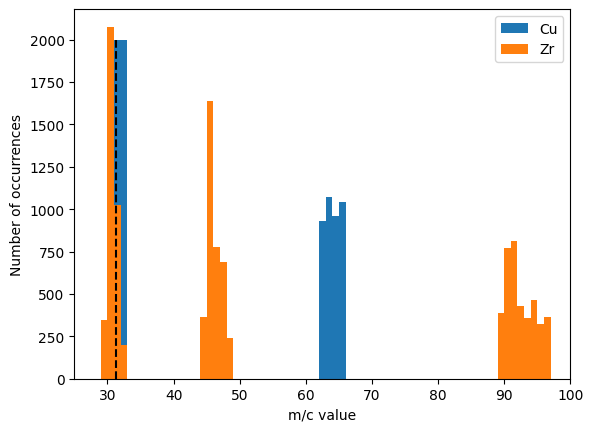

In [21]:
# Checking presence of peaks in synthetic training data

plt.clf()
bins = np.arange(0, 200, 1)

mc_list = list()
counts_list = list()
for i, j, k in zip(mc, counts, ions):
  if k == 'Cu':
    mc_list.append(i)
    counts_list.append(j)
plt.hist(mc_list, bins, label='Cu')

mc_list = list()
counts_list = list()
for i, j, k in zip(mc, counts, ions):
  if k == 'Zr':
    mc_list.append(i)
    counts_list.append(j)
plt.hist(mc_list, bins, label='Zr')

plt.legend(loc='best')
plt.xlabel('m/c value')
plt.ylabel('Number of occurrences')
plt.plot([31.26, 31.26], [0, 2000], 'k--')
plt.xlim(25, 100)

INFO:apav:Reading apt file: /content/drive/MyDrive/Cameca/R13_40310Zr Unsaved - Top Level ROI.apt


Start inference
Speed:  450.0ms inference, 41.8ms postprocess for per spectrum 


INFO:apav:Reading apt file: /content/drive/MyDrive/Cameca/R13_40310Zr Unsaved - Top Level ROI.apt


model predicted peaks: 36
model predicted total peaks torch.Size([36, 2]) torch.Size([36])


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
INFO:apav:Reading apt file: /content/drive/MyDrive/Cameca/R13_40310Zr Unsaved - Top Level ROI.apt


<Figure size 640x480 with 0 Axes>

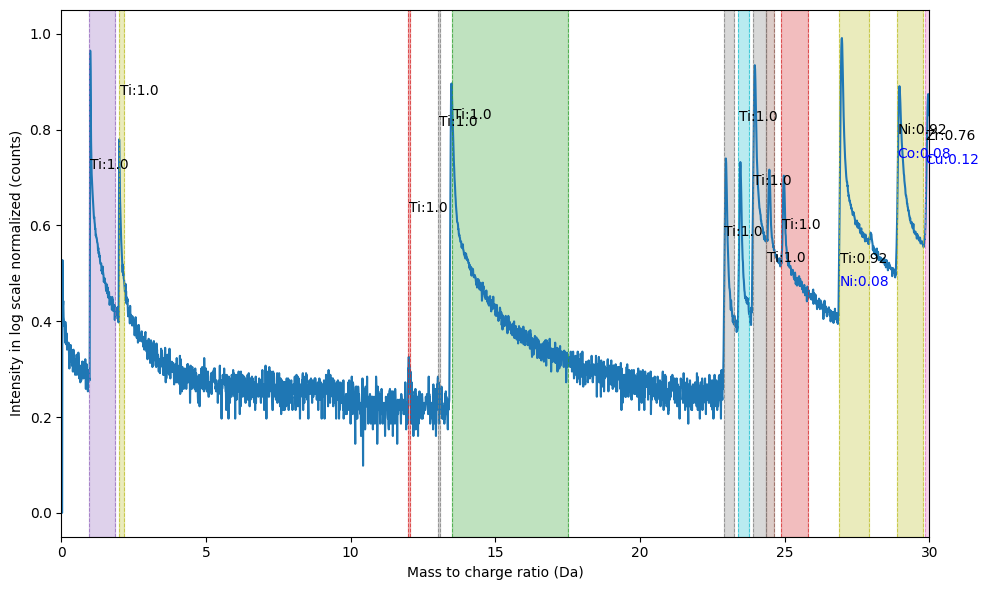

In [ ]:
# Load in an .apt file and run both the ranging and ion classification models,
# then plot the results. This block uses in-development Random forest model

# Update the path to the .apt file you want to use the models on
apt_file = '/content/drive/MyDrive/Cameca/R13_40310Zr Unsaved - Top Level ROI.apt'

peak_range_pred, counts, result = predict_peak_ranges(apt_file,
                                                      conf=0.05,
                                                      iou=0.01,
                                                      max_det=2000,
                                                      modelpath='peak_detection/RangingNN/modelweights/best.pt',
                                                      n_iter=0)

elements, second_elements, confs, second_confs, X = run_RF_model(peak_range_pred,
                                                                 counts,
                                                                 scaler,
                                                                 model,
                                                                 target_decoder,
                                                                 use_peak_maxima=True,
                                                                 apt_file=apt_file)

plot_predictions(apt_file=apt_file,
                 peak_range_pred=peak_range_pred,
                 res=elements,
                 confidence=confs,
                 plot_min=0,
                 plot_max=3000, #7100
                 resort=False,
                 res2=second_elements,
                 confidence2=second_confs,
                  output_dir=os.getcwd())

INFO:apav:Reading RRNG file: /content/drive/MyDrive/Cameca/data_from_David/R13_40310Zr Top Level ROI.RRNG


**************************
ANALYZING FILE /content/drive/MyDrive/Cameca/R13_40310Zr Unsaved - Top Level ROI.apt /content/drive/MyDrive/Cameca/data_from_David/R13_40310Zr Top Level ROI.RRNG
**************************


INFO:apav:Reading apt file: /content/drive/MyDrive/Cameca/R13_40310Zr Unsaved - Top Level ROI.apt
INFO:apav:Reading apt file: /content/drive/MyDrive/Cameca/R13_40310Zr Unsaved - Top Level ROI.apt


Start inference
Speed:  152.9ms inference, 8.1ms postprocess for per spectrum 


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
INFO:apav:Reading apt file: /content/drive/MyDrive/Cameca/R13_40310Zr Unsaved - Top Level ROI.apt


model predicted peaks: 36
model predicted total peaks torch.Size([36, 2]) torch.Size([36])
Random Forest Ion classification results
0.7272727272727273 0.8571428571428571
RF Final stats over all files, including molecules then not
0.7272727272727273
0.8571428571428571
YOLO Final stats over all files
0.9166666666666666 0.9705882352941176 0.9428571428571428


<Figure size 640x480 with 0 Axes>

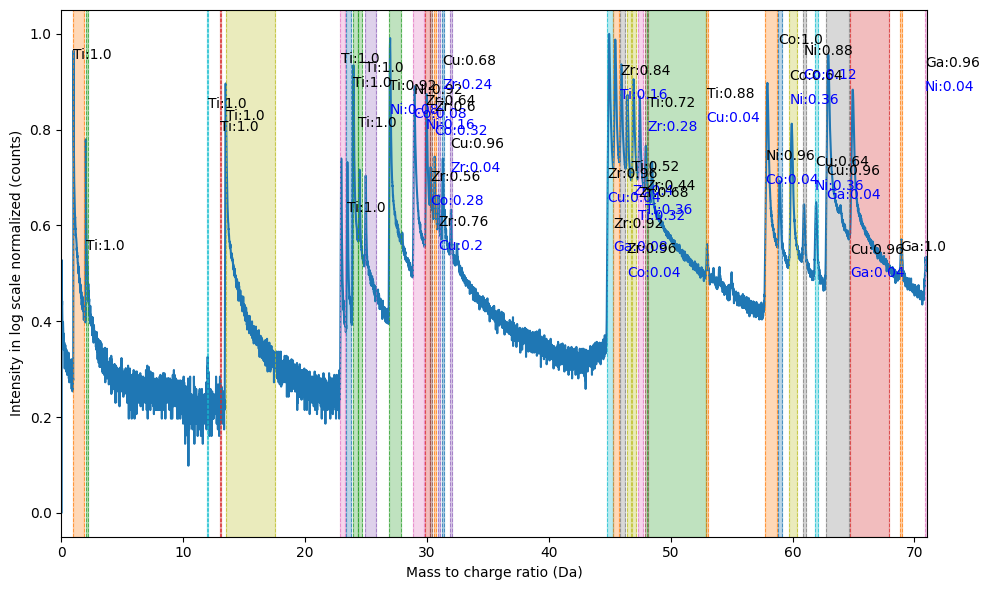

In [ ]:
apt_files = ['/content/drive/MyDrive/Cameca/R13_40310Zr Unsaved - Top Level ROI.apt']
rrng_files = ['/content/drive/MyDrive/Cameca/data_from_David/R13_40310Zr Top Level ROI.RRNG']

df_stats = run_evaluation(output_dir='results',
                  apt_files = apt_files,
                  rrng_files = rrng_files,
                  scaler = scaler,
                  model = model,
                  target_decoder = target_decoder,
                  peak_finder_iou = 0.01,
                  peak_finder_conf = 0.05,
                  use_true_peaks=False,
                  modelpath='peak_detection/RangingNN/modelweights/best.pt')


# Now we want to run the error checking function to try suggesting new elements that may have been missed


In [ ]:
# Make the error checking lookup model

lookup_model = make_lookup_model(make_plot=False, xmin=0, xmax=200)


Loading and parsing classifier training data: 100%|██████████| 1000/1000 [00:06<00:00, 146.02it/s]


In [ ]:
# Sort predictions just to make examination easier

peak_range_pred_sort, elements_sort = sort_predictions(peak_range_pred, elements)
_, second_elements_sort = sort_predictions(peak_range_pred, second_elements)

In [ ]:
# Run the error checking routine to suggest new elements

check_for_errors(peak_range_pred_sort, elements_sort, second_elements_sort, lookup_model, thresh=0.01, num_elements=3)

Predicted element Ti at peak onset tensor(0.9568) is far from lookup predictions of ['H', 'Li', 'Be']
Predicted element Ti at peak onset tensor(1.9924) is far from lookup predictions of ['H', 'Li', 'Be']
Predicted element Ti at peak onset tensor(11.9943) is far from lookup predictions of ['Mg', 'C', 'B']
Predicted element Ti at peak onset tensor(13.0210) is far from lookup predictions of ['Mg', 'C', 'Al']
Predicted element Ti at peak onset tensor(13.5167) is far from lookup predictions of ['Al', 'N', 'Si']
Predicted element Ti at peak onset tensor(26.8853) is far from lookup predictions of ['Al', 'Cr', 'Mn']
Predicted element Ti at peak onset tensor(52.9210) is far from lookup predictions of ['Cr', 'Pd', 'Ru']


# Misc stuff here

In [ ]:
df_stats

,"RF stats over all files, including molecules","RF stats over all files, elements only",Total number of peaks over all files,Total number of predicted peaks over all files,Total number of found peaks over all files,Peak finder precision over all files,Peak finder recall over all files,Peak finder F1 over all files
0,0.848485,0.933333,34,36,33,0.916667,0.970588,0.942857


In [ ]:
rng = apav.load_rrng(rrng_files[0])

all_trues = list()
for i in rng:
    all_trues.append(i.hill_formula)

np.unique(all_trues)

INFO:apav:Reading RRNG file: /content/drive/MyDrive/Cameca/data_from_David/R13_40310Zr Top Level ROI.RRNG


array(['Al', 'C', 'Co', 'Cu', 'Ga', 'H', 'H2', 'HZr', 'Ni', 'Ti', 'Zr'],
      dtype='<U3')

In [ ]:
# Load in all the training data
element_list = ['H', 'He', 'Li', 'Be', 'B', 'C', 'N', 'O', 'F', 'Ne', 'Na', 'Mg', 'Al',
                         'Si', 'P', 'S', 'Cl', 'Ar', 'K', 'Ca', 'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe',
                         'Co', 'Ni', 'Cu', 'Zn', 'Ga', 'Ge', 'As', 'Se', 'Br', 'Kr', 'Rb', 'Sr',
                         'Y', 'Zr', 'Nb', 'Mo', 'Ru', 'Rh', 'Pd', 'Ag', 'Cd', 'In', 'Sn', 'Sb',
                         'Te', 'I', 'Xe', 'Cs', 'Ba', 'La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd',
                         'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Lu', 'Hf', 'Ta', 'W', 'Re', 'Os', 'Ir',
                         'Pt', 'Au', 'Hg', 'Tl', 'Pb', 'Bi', 'Th', 'U']
mc, counts, ions = load_ion_training_data(path='peak_detection/Ionclassifier/training_data/NewData/Data0001',
                                          element_list = element_list,
                                          elements_to_get_molecules=list(),
                                          threshold_c= 1e-8,
                                          num_files=1000)

Loading and parsing classifier training data:  65%|██████▍   | 648/1000 [00:04<00:02, 148.33it/s]


KeyboardInterrupt: 

Loading and parsing classifier training data: 100%|██████████| 1000/1000 [00:04<00:00, 241.89it/s]


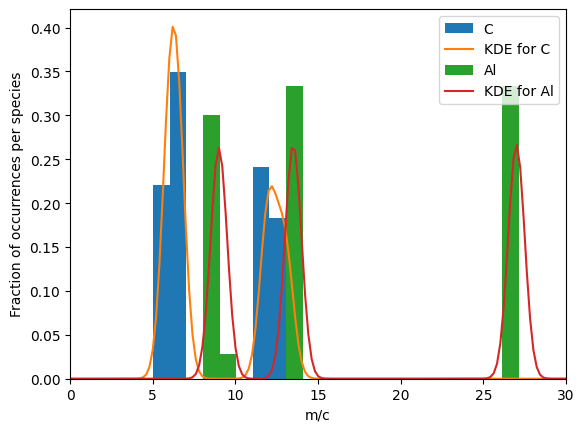

In [ ]:
lookup_model = make_lookup_model(make_plot=True, xmin=0, xmax=30)

In [ ]:
# Group the mc and counts by ion as a look-up mechanism
lookup_dict = dict()
for mc1, count, ion in zip(mc, counts, ions):
  if ion not in lookup_dict.keys():
    lookup_dict[ion] = list()
  lookup_dict[ion].append(mc1)

In [ ]:
lookup_dict.keys()

dict_keys(['H', 'C', 'N', 'O', 'P', 'Fe', 'Co', 'Zr', 'Zn', 'Pd', 'Sn', 'Sr', 'Bi', 'Th', 'S', 'Cu', 'W', 'Mo', 'Se', 'Te', 'Tl', 'Mn', 'Ba', 'Hf', 'La', 'Li', 'Au', 'Cd', 'Gd', 'Tm', 'F', 'V', 'Mg', 'Cr', 'Ni', 'As', 'K', 'Sb', 'Ta', 'Br', 'Rb', 'Os', 'Nd', 'Sm', 'Nb', 'Pt', 'Ag', 'Cs', 'Ti', 'B', 'Si', 'Ru', 'Pr', 'Eu', 'Ge', 'Re', 'Dy', 'Tb', 'Na', 'Ga', 'Rh', 'U', 'Y', 'Pb', 'In', 'Cl', 'Be', 'Ce', 'Hg', 'Er', 'Ir', 'Lu', 'Ca', 'Al', 'Ho', 'I', 'Sc'])

In [ ]:
mc

array([  1.05,   6.03,   6.49, ..., 178.02, 179.01, 180.01])

H
C
N
O
P
Fe
Co
Zr
Zn
Pd
Sn
Sr
Bi
Th
S
Cu
W
Mo
Se
Te
Tl
Mn
Ba
Hf
La
Li
Au
Cd
Gd
Tm
F
V
Mg
Cr
Ni
As
K
Sb
Ta
Br
Rb
Os
Nd
Sm
Nb
Pt
Ag
Cs
Ti
B
Si
Ru
Pr
Eu
Ge
Re
Dy
Tb
Na
Ga
Rh
U
Y
Pb
In
Cl
Be
Ce
Hg
Er
Ir
Lu
Ca
Al
Ho
I
Sc


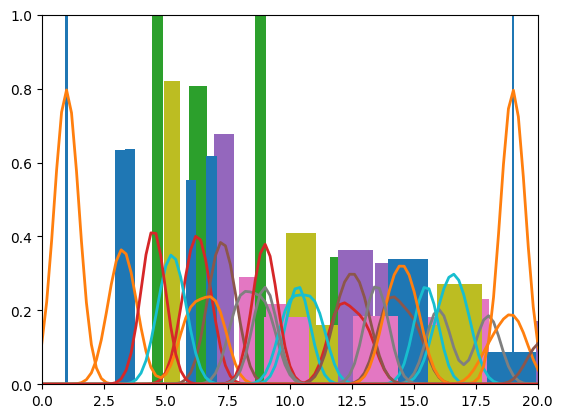

In [ ]:
lookup_dict_dens = dict()
for k in lookup_dict.keys():

  print(k)
  data = np.array(lookup_dict[k])

  histcounts, bin_edges, patches = plt.hist(data, density=True)

  # Fit KDE with bandwidth chosen via grid search or rule of thumb
  x_plot = np.linspace(0, 200, 1000).reshape(-1, 1)
  kde = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(data.reshape(-1, 1))
  log_dens = kde.score_samples(x_plot)

  if k not in lookup_dict_dens.keys():
      lookup_dict_dens[k] = kde #np.exp(log_dens)

  plt.plot(x_plot, np.exp(log_dens), label='KDE (scikit-learn)', lw=2)

  plt.xlim(0, 20)
  plt.ylim(0, 1)

In [ ]:
# Get ranking of possible elements for new data point
x0 = np.array([[25.4]])
ranking_dict = dict()
for k in lookup_dict_dens.keys():
  if k not in ranking_dict.keys():
    log_prob = lookup_dict_dens[k].score_samples(x0)     # log(f(x0))
    pdf_value = np.exp(log_prob)[0]
    ranking_dict[k] = pdf_value

prediction_rankings = sorted(ranking_dict.items(), key=lambda x: x[1], reverse=True)
prediction_rankings

[('V', np.float64(0.34869705363232767)),
 ('Mg', np.float64(0.15993262034802389)),
 ('Cr', np.float64(0.12301781958045654)),
 ('Ti', np.float64(0.06622817246279103)),
 ('Al', np.float64(0.0016103463787419982)),
 ('Ca', np.float64(0.0011466398244678448)),
 ('Fe', np.float64(0.00039336038864150915)),
 ('Mn', np.float64(6.211850690945616e-05)),
 ('Na', np.float64(8.632445724123275e-06)),
 ('Si', np.float64(1.9411865766958962e-07)),
 ('Sc', np.float64(2.2021927485484637e-08)),
 ('Ni', np.float64(5.564669009778521e-13)),
 ('Co', np.float64(1.1621830280450143e-15)),
 ('Zr', np.float64(2.6254410472713248e-20)),
 ('P', np.float64(1.319367149757237e-28)),
 ('Cu', np.float64(1.2710592208166126e-33)),
 ('F', np.float64(2.9449095162733527e-36)),
 ('Zn', np.float64(1.0717922740134748e-39)),
 ('S', np.float64(4.0925705665293625e-40)),
 ('O', np.float64(7.473266662482898e-49)),
 ('Ga', np.float64(4.203588628923638e-73)),
 ('Cl', np.float64(6.521629250171661e-81)),
 ('Ge', np.float64(1.253540099570666

In [ ]:


def make_lookup_model():
    # Load in all the training data
    element_list = ['H', 'He', 'Li', 'Be', 'B', 'C', 'N', 'O', 'F', 'Ne', 'Na', 'Mg', 'Al',
                         'Si', 'P', 'S', 'Cl', 'Ar', 'K', 'Ca', 'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe',
                         'Co', 'Ni', 'Cu', 'Zn', 'Ga', 'Ge', 'As', 'Se', 'Br', 'Kr', 'Rb', 'Sr',
                         'Y', 'Zr', 'Nb', 'Mo', 'Ru', 'Rh', 'Pd', 'Ag', 'Cd', 'In', 'Sn', 'Sb',
                         'Te', 'I', 'Xe', 'Cs', 'Ba', 'La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd',
                         'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Lu', 'Hf', 'Ta', 'W', 'Re', 'Os', 'Ir',
                         'Pt', 'Au', 'Hg', 'Tl', 'Pb', 'Bi', 'Th', 'U']
    mc, counts, ions = load_ion_training_data(path='peak_detection/Ionclassifier/training_data/NewData/Data0001',
                                          element_list = element_list,
                                          elements_to_get_molecules=list(),
                                          threshold_c= 1e-8,
                                          num_files=1000)

    # Group the mc and counts by ion as a look-up mechanism
    lookup_dict = dict()
    for mc1, count, ion in zip(mc, counts, ions):
        if ion not in lookup_dict.keys():
            lookup_dict[ion] = list()
        lookup_dict[ion].append(mc1)

    lookup_dict_dens = dict()
    for k in lookup_dict.keys():
        #print(k)
        data = np.array(lookup_dict[k])

        histcounts, bin_edges, patches = plt.hist(data, density=True)

        # Fit KDE with bandwidth chosen via grid search or rule of thumb
        x_plot = np.linspace(0, 200, 1000).reshape(-1, 1)
        kde = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(data.reshape(-1, 1))
        log_dens = kde.score_samples(x_plot)

        if k not in lookup_dict_dens.keys():
            lookup_dict_dens[k] = kde #np.exp(log_dens)

    lookup_model = lookup_dict_dens
    return lookup_model

def predict_lookup_model(lookup_model, x, num_top_elements=3):
    # Get ranking of possible elements for new data point
    #x0 = np.array([[25.4]])
    ranking_dict = dict()
    for k in lookup_model.keys():
      if k not in ranking_dict.keys():
        log_prob = lookup_model[k].score_samples(x)     # log(f(x0))
        pdf_value = np.exp(log_prob)[0]
        ranking_dict[k] = pdf_value

    prediction_rankings = sorted(ranking_dict.items(), key=lambda x: x[1], reverse=True)
    preds = prediction_rankings[:num_top_elements]
    pred_ions = [i[0] for i in preds]
    confs = [i[1] for i in preds]
    return pred_ions, confs

# Try idea of multiple rounds of peak ID to find more peaks

INFO:apav:Reading RRNG file: drive/MyDrive/Cameca/Data_hdf5s/ALL_RRNG/R40_110290Au.RRNG
INFO:apav:Reading apt file: drive/MyDrive/Cameca/Data_hdf5s/ALL_APT/R40_110290-v01 AuAlloy.apt
INFO:apav:Reading apt file: drive/MyDrive/Cameca/Data_hdf5s/ALL_APT/R40_110290-v01 AuAlloy.apt


spectrum log
torch.Size([30720])
tensor([0.5120, 0.4539, 0.4321,  ..., 0.1278, 0.1278, 0.1651])
Start inference
Speed:  82.0ms inference, 7.5ms postprocess for per spectrum 


INFO:apav:Reading apt file: drive/MyDrive/Cameca/Data_hdf5s/ALL_APT/R40_110290-v01 AuAlloy.apt


model predicted peaks: 58


(33.0, 35.0)

<Figure size 640x480 with 0 Axes>

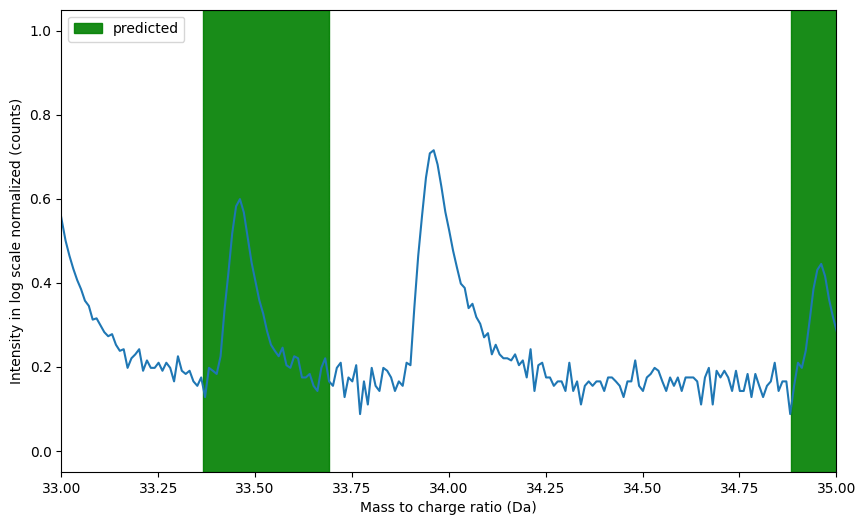

In [ ]:
rrng = 'drive/MyDrive/Cameca/Data_hdf5s/ALL_RRNG/R40_110290Au.RRNG'
apt_file = 'drive/MyDrive/Cameca/Data_hdf5s/ALL_APT/R40_110290-v01 AuAlloy.apt'

rng = apav.load_rrng(rrng)
d = apav.load_apt(apt_file)
x, spectrum = d.mass_histogram(bin_width=0.01, lower=0, upper=307.2, multiplicity='all', norm=False,)
spectrum_log = torch.tensor(map01(np.log(spectrum+1)), dtype=torch.float32)

lsts = list()
for i in rng:
    #all_trues.append(i.hill_formula)
    lsts.append(np.array([1000*i.lower, 1000*i.upper]))
true_ranges = np.array(lsts)

# Get peak ranges
peak_range_pred, counts, result = predict_peak_ranges(apt_file,
                                                      conf=0.05,
                                                      iou=0.01,
                                                      max_det=2000,
                                                      modelpath='peak_detection/RangingNN/modelweights/best.pt')
plot_min = 3300 #0
plot_max = 3500 #20000
multiplier = 0.01
multiplier2 = 1.0
multiplier3 = 0.001

#colors = list(mcolors.TABLEAU_COLORS.values())
#color_inds = [int(np.random.uniform(0, len(colors))) for _ in range(peak_range_pred.shape[0])]

plt.clf()
plt.figure(figsize=(10, 6))
spectrum, spectrum_log = load_apt(apt_file=apt_file)

x = np.linspace(0.0, spectrum_log.shape[0]*0.01, spectrum_log.shape[0])
plt.plot(x, spectrum_log)

# Add color boxes for each peak range
# Add vertical lines to show the boundaries of ranges

peak_pred_ = peak_range_pred[(peak_range_pred[:,0]*multiplier2 < plot_max) & (peak_range_pred[:,0]*multiplier2 > plot_min)]


count = 0
for start, end in peak_pred_:
    if count == 0:
        plt.axvspan(start*multiplier, end*multiplier, alpha=0.9, color='green', label='predicted')#colors[color_inds[count]])
    else:
        plt.axvspan(start*multiplier, end*multiplier, alpha=0.9, color='green')#colors[color_inds[count]])
    plt.axvline(start*multiplier, color='green', linestyle='--', alpha=0.1, lw = 0.7) #color=colors[color_inds[count]]
    plt.axvline(end*multiplier, color='green', linestyle='--', alpha=0.1, lw = 0.7)
    count += 1
#'''
# Add trues as well
count = 0
for start, end in true_ranges:
    if count == 0:
        plt.axvspan(start*multiplier3, end*multiplier3, alpha=0.3, color='blue', label='true')#colors[color_inds[count]])
    else:
        plt.axvspan(start*multiplier3, end*multiplier3, alpha=0.3, color='blue')#colors[color_inds[count]])
    plt.axvline(start*multiplier3, color='blue', linestyle='--', alpha=0, lw = 0.7) #color=colors[color_inds[count]]
    plt.axvline(end*multiplier3, color='blue', linestyle='--', alpha=0, lw = 0.7)
    count += 1
#'''

# Set labels and title
plt.xlabel('Mass to charge ratio (Da)')
plt.ylabel('Intensity in log scale normalized (counts)')
plt.legend(loc='best')

plt.xlim(0.01*plot_min, 0.01*plot_max)


In [ ]:
idx_delete = list()
for i, j in zip(x, spectrum_log):
    for start, end in peak_pred_:
        if start*multiplier < i < end*multiplier:
            idx_delete.append(i)

In [ ]:


# Sub a constant 0.2 in for now
spectrum_log_mod = list()
for i, j in zip(x, spectrum_log):
    if i in idx_delete:
        spectrum_log_mod.append(0.2)
    else:
        spectrum_log_mod.append(j)

spectrum_log_mod = torch.Tensor(spectrum_log_mod)
spectrum_log_mod

tensor([0.5120, 0.4539, 0.4321,  ..., 0.1278, 0.1278, 0.1651])

In [ ]:
spectrum_log_mod

tensor([0.5120, 0.4539, 0.4321,  ..., 0.1278, 0.1278, 0.1651])

spectrum log
torch.Size([30720])
tensor([0.5120, 0.4539, 0.4321,  ..., 0.1278, 0.1278, 0.1651])
Start inference
Speed:  85.9ms inference, 8.1ms postprocess for per spectrum 
model predicted peaks: 57


/tmp/ipython-input-983074431.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


(33.0, 35.0)

<Figure size 640x480 with 0 Axes>

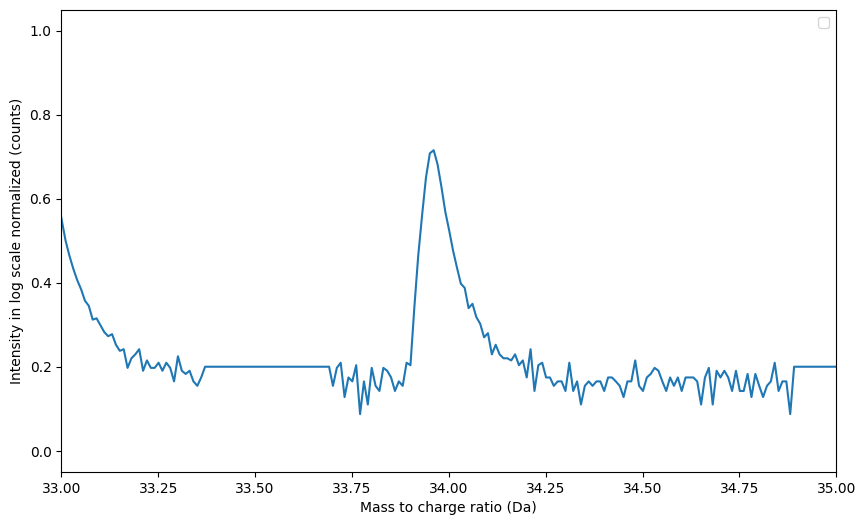

In [ ]:
# Now re-plot the data
plot_min = 3300 #0
plot_max = 3500 #20000
multiplier = 0.01
multiplier2 = 1.0
multiplier3 = 0.001

#colors = list(mcolors.TABLEAU_COLORS.values())
#color_inds = [int(np.random.uniform(0, len(colors))) for _ in range(peak_range_pred.shape[0])]

peak_range_pred_mod, counts, result = predict_peak_ranges(apt_file,
                                                      conf=0.05,
                                                      iou=0.01,
                                                      max_det=2000,
                                                      modelpath='peak_detection/RangingNN/modelweights/best.pt',
                                                      from_custom_spectrum=True,
                                                      spectrum_log=spectrum_log_mod)

plt.clf()
plt.figure(figsize=(10, 6))
#spectrum, spectrum_log = load_apt(apt_file=apt_file)

#x = np.linspace(0.0, spectrum_log.shape[0]*0.01, spectrum_log.shape[0])
plt.plot(x, spectrum_log_mod)

# Add color boxes for each peak range
# Add vertical lines to show the boundaries of ranges

peak_pred_mod = peak_range_pred_mod[(peak_range_pred_mod[:,0]*multiplier2 < plot_max) & (peak_range_pred_mod[:,0]*multiplier2 > plot_min)]

'''
count = 0
for start, end in peak_pred_mod:
    if count == 0:
        plt.axvspan(start*multiplier, end*multiplier, alpha=0.9, color='green', label='predicted')#colors[color_inds[count]])
    else:
        plt.axvspan(start*multiplier, end*multiplier, alpha=0.9, color='green')#colors[color_inds[count]])
    plt.axvline(start*multiplier, color='green', linestyle='--', alpha=0.1, lw = 0.7) #color=colors[color_inds[count]]
    plt.axvline(end*multiplier, color='green', linestyle='--', alpha=0.1, lw = 0.7)
    count += 1
'''
# Add trues as well
'''
count = 0
for start, end in true_ranges:
    if count == 0:
        plt.axvspan(start*multiplier3, end*multiplier3, alpha=0.3, color='blue', label='true')#colors[color_inds[count]])
    else:
        plt.axvspan(start*multiplier3, end*multiplier3, alpha=0.3, color='blue')#colors[color_inds[count]])
    plt.axvline(start*multiplier3, color='blue', linestyle='--', alpha=0, lw = 0.7) #color=colors[color_inds[count]]
    plt.axvline(end*multiplier3, color='blue', linestyle='--', alpha=0, lw = 0.7)
    count += 1
'''

# Set labels and title
plt.xlabel('Mass to charge ratio (Da)')
plt.ylabel('Intensity in log scale normalized (counts)')
plt.legend(loc='best')

plt.xlim(0.01*plot_min, 0.01*plot_max)

In [ ]:
peak_pred_

tensor([[3001.9927, 3018.9556],
        [2793.2568, 2802.6123],
        [1403.9102, 1410.2441],
        [1807.4354, 1813.7072],
        [3391.4814, 3408.0986]])

In [ ]:
idx_delete

[np.float64(11.980389986653211),
 np.float64(11.99039031218464),
 np.float64(12.000390637716071),
 np.float64(12.0103909632475),
 np.float64(12.480406263224713),
 np.float64(12.490406588756143),
 np.float64(12.500406914287574),
 np.float64(13.48043881636772),
 np.float64(13.490439141899149),
 np.float64(13.50043946743058),
 np.float64(13.510439792962009),
 np.float64(13.960454441876362),
 np.float64(13.970454767407793),
 np.float64(13.980455092939222),
 np.float64(13.990455418470653),
 np.float64(14.000455744002082),
 np.float64(14.010456069533513),
 np.float64(14.020456395064942),
 np.float64(14.030456720596373),
 np.float64(14.040457046127802),
 np.float64(14.050457371659233),
 np.float64(14.060457697190662),
 np.float64(14.470471043979295),
 np.float64(14.480471369510726),
 np.float64(14.490471695042155),
 np.float64(14.500472020573586),
 np.float64(14.510472346105015),
 np.float64(14.980487646082228),
 np.float64(14.990487971613659),
 np.float64(15.000488297145088),
 np.float64(15.